# 3. Water content of the gas phase, mixed gases and enthalpy of solution

<a href="https://colab.research.google.com/github/jmoortgat/GasBrineBench/blob/main/notebooks/03_water_content_mixtures_enthalpy.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


* `y_h2o.csv`: mole fraction of water in the gas-rich phase, against pressure and temperature, and as an **enhancement factor**
  f = y P / p_sat(T) that removes the leading temperature dependence and shows deviations from an ideal mixture.
* `ternary.csv`: CO2 + CH4 + water, with the gas-phase split as an explicit variable.
* `dh_sol.csv`: calorimetric enthalpy of dissolution of gases in water.

> **Running on Google Colab?** Click the badge above and run the cells; nothing needs to be installed. The first code cell detects
> Colab, clones the repository into `/content/GasBrineBench`, checks that pandas, numpy and matplotlib are present (Colab already has them)
> and changes into `notebooks/`, so everything after it works as on a local checkout. Locally the cell does nothing but confirm the layout.
> To use a fork or a branch, set `GBB_REPO_URL` and `GBB_BRANCH` before the cell runs.

In [1]:
# --- Colab / local bootstrap ---------------------------------------------------------------------------------
# On Colab this cell clones the repository and installs anything missing; on a local checkout it only confirms the layout.
# Re-running it is safe.
import os, subprocess, sys
from pathlib import Path

REPO_URL = os.environ.get("GBB_REPO_URL", "https://github.com/jmoortgat/GasBrineBench.git")
BRANCH = os.environ.get("GBB_BRANCH", "main")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB or os.environ.get("GBB_FORCE_BOOTSTRAP"):
    REPO_DIR = Path("/content/GasBrineBench") if IN_COLAB else Path(os.environ.get("GBB_CLONE_DIR", "GasBrineBench_clone")).resolve()
    if not REPO_DIR.exists():
        print(f"cloning {REPO_URL} ({BRANCH}) into {REPO_DIR}")
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f"repository already cloned at {REPO_DIR}")
    missing = []
    for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("pip install -q", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    os.chdir(REPO_DIR / "notebooks")
    print("cwd =", os.getcwd())
else:
    print("local environment: using the existing checkout")

local environment: using the existing checkout


In [2]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd()
ROOT = HERE if (HERE / "gasbrinebench").exists() else HERE.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "notebooks"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gasbrinebench as gbb
from gasbrinebench.vocab import DEFAULT_EXCLUDED_FLAGS
import gbb_viz as V
V.style()
# default view (what a benchmark user scores) and the view that also keeps rows without a stated pressure
df = gbb.load()
dfp = gbb.load(exclude_flags=tuple(f for f in DEFAULT_EXCLUDED_FLAGS if f != "pressure-unstated"))
dfall = gbb.load(exclude_tags=None, exclude_flags=None)
print(f"{len(dfall):,} rows in total, {len(df):,} in the default view, gasbrinebench {gbb.__version__}")

27,025 rows in total, 23,300 in the default view, gasbrinebench 1.2.0


In [3]:
y = df[(df.property == "y_h2o")]
yw = y[y.total_molality == 0].copy()
yw["psat"] = V.wagner_psat_bar(yw.T_K.clip(upper=647.0))
yw["enh"] = yw.value * yw.P_bar / yw.psat
print(yw.groupby("gas").agg(rows=("value", "size"), sources=("source", "nunique"), T_min=("T_K", "min"), T_max=("T_K", "max")).round(1))

         rows  sources  T_min  T_max
gas                                 
c2h6      179        8  278.1  510.9
c3h8      105        4  273.2  493.2
ch4       319       12  277.8  510.9
co2       685       24  275.2  623.2
co2-ch4    10        1  323.2  423.2
h2          9        1  273.2  283.2
n2        138        6  274.1  503.2


## Water mole fraction against pressure, by temperature (pure water, per gas)

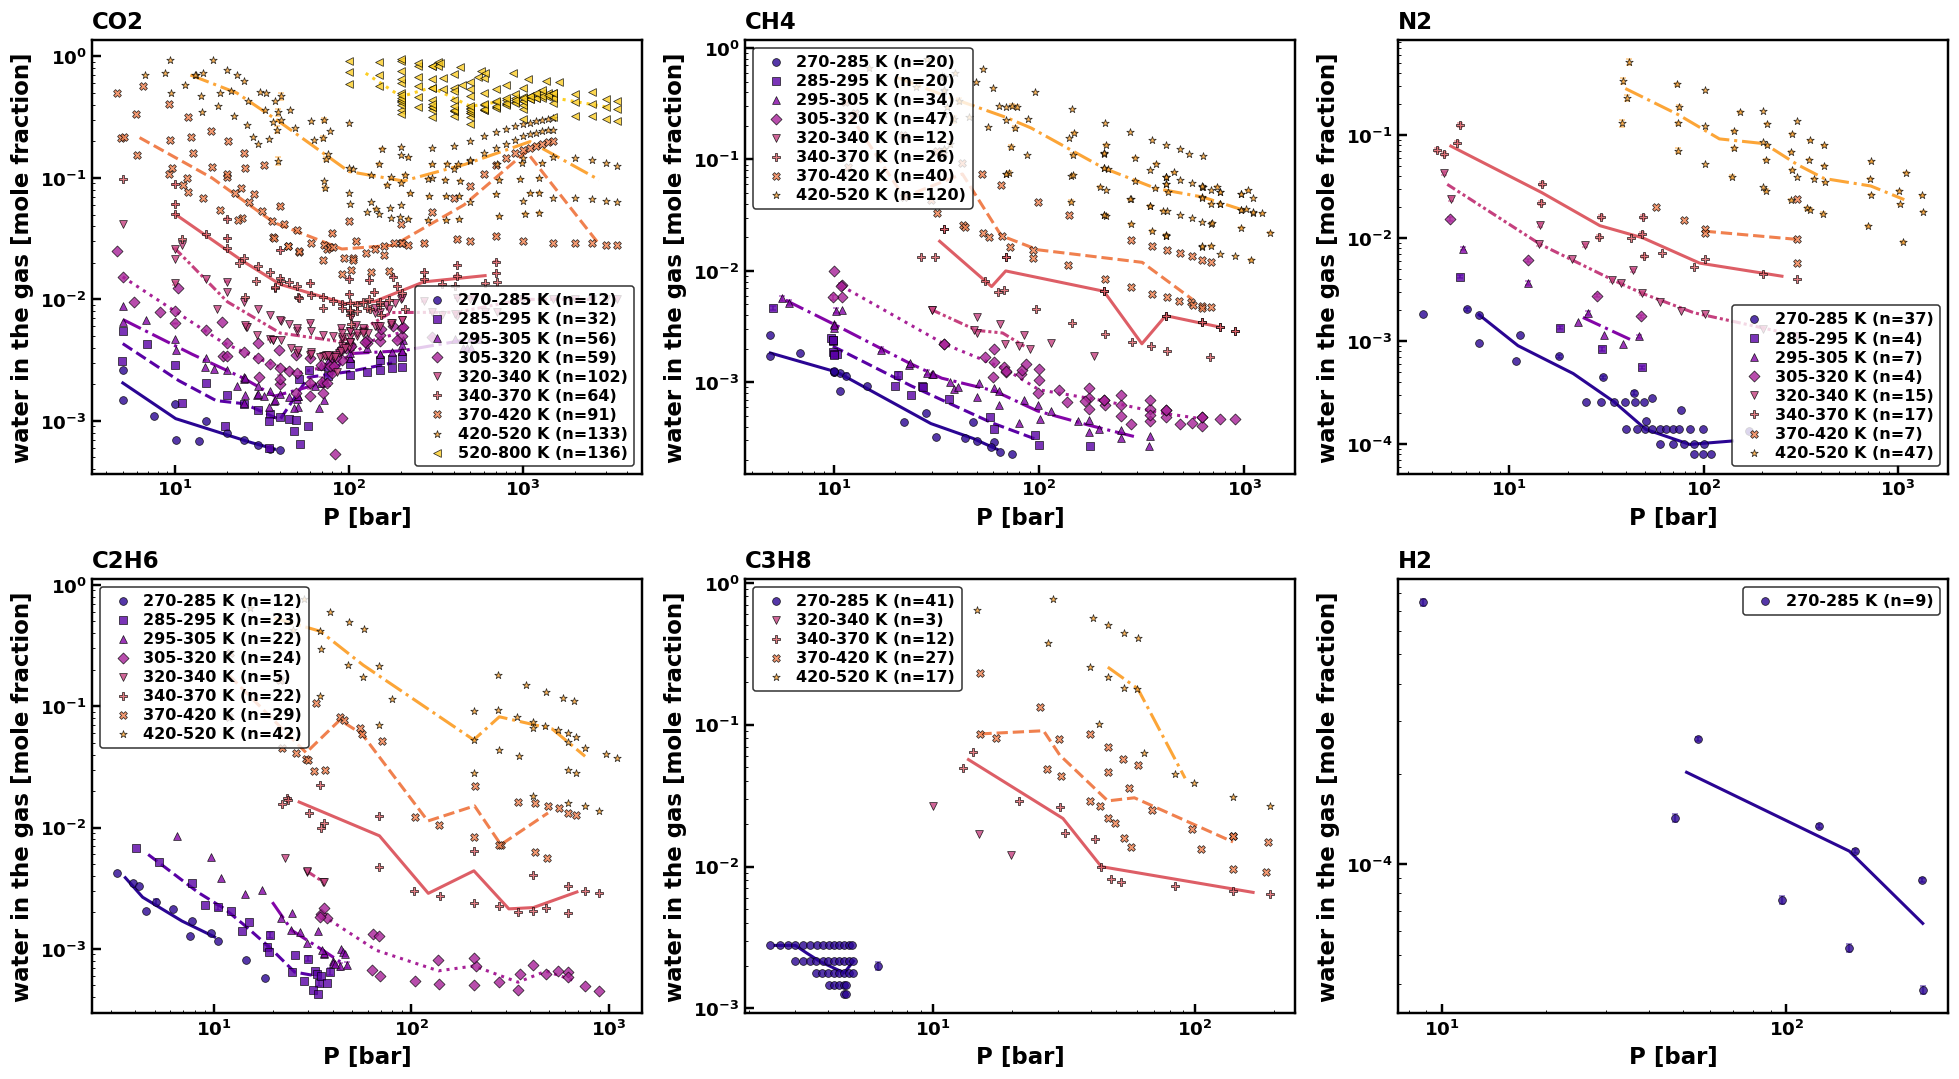

In [4]:
gases = [g for g in ["co2", "ch4", "n2", "c2h6", "c3h8", "h2"] if (yw.gas == g).sum() >= 8]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, gas in zip(axes.ravel(), gases):
    V.isotherms(ax, yw[yw.gas == gas], y="value", err=True)
    V.lab(ax, "P [bar]", "water in the gas [mole fraction]", V.GAS_LABEL[gas])
plt.tight_layout(); plt.show()

## Enhancement factor

f = y P / p_sat(T) is 1 for an ideal gas mixture and rises with pressure through the fugacity coefficient of water and the
Poynting correction. On this scale the gases can be compared directly, and a source that disagrees with its neighbours stands out.

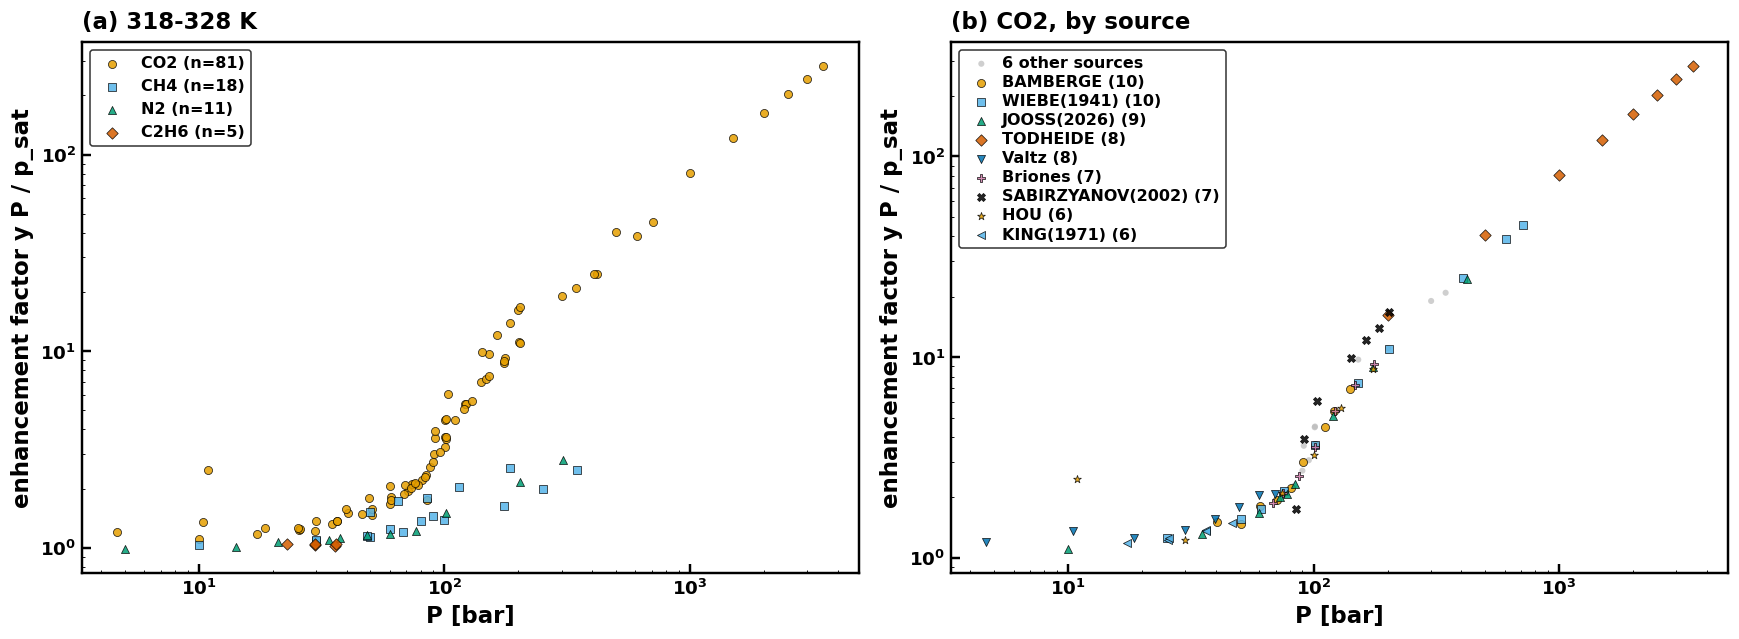

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for k, gas in enumerate(gases):
    g = yw[(yw.gas == gas) & yw.T_K.between(318, 328)]
    if len(g) == 0: continue
    axes[0].scatter(g.P_bar, g.enh, s=28, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], edgecolor="black", linewidth=0.5, alpha=0.85, label=f"{V.GAS_LABEL[gas]} (n={len(g)})")
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].legend(); V.lab(axes[0], "P [bar]", "enhancement factor y P / p_sat", "(a) 318-328 K")
g = yw[(yw.gas == "co2") & yw.T_K.between(318, 328)]
V.by_source(axes[1], g, y="enh", top=9); V.lab(axes[1], "P [bar]", "enhancement factor y P / p_sat", "(b) CO2, by source")
plt.tight_layout(); plt.show()

## Effect of salt on the water content (CO2 and CH4)

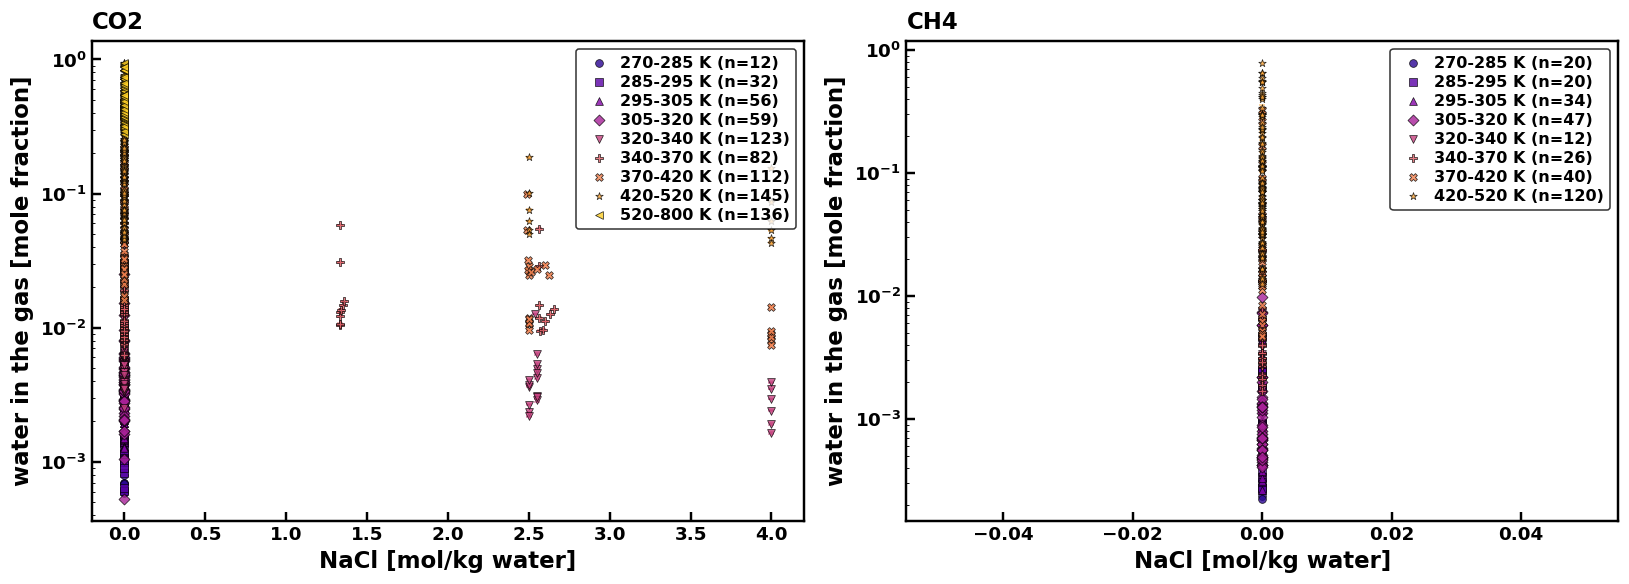

In [6]:
ys = y[(y.salt_system.isin(["water", "Na-Cl"]))]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, gas in zip(axes, ["co2", "ch4"]):
    g = ys[ys.gas == gas].copy(); g["m_NaCl"] = g.m_Na
    V.isotherms(ax, g, x="m_NaCl", y="value", logx=False, logy=True, trend_line=False)
    V.lab(ax, "NaCl [mol/kg water]", "water in the gas [mole fraction]", V.GAS_LABEL[gas])
plt.tight_layout(); plt.show()

## CO2 + CH4 + water

`ternary.csv` carries the gas-phase CO2 fraction (water-free) `y_co2_dry`. The dissolved amounts of both gases and the water content of
the mixed gas change with it, which is why the split is a state variable and not a label.

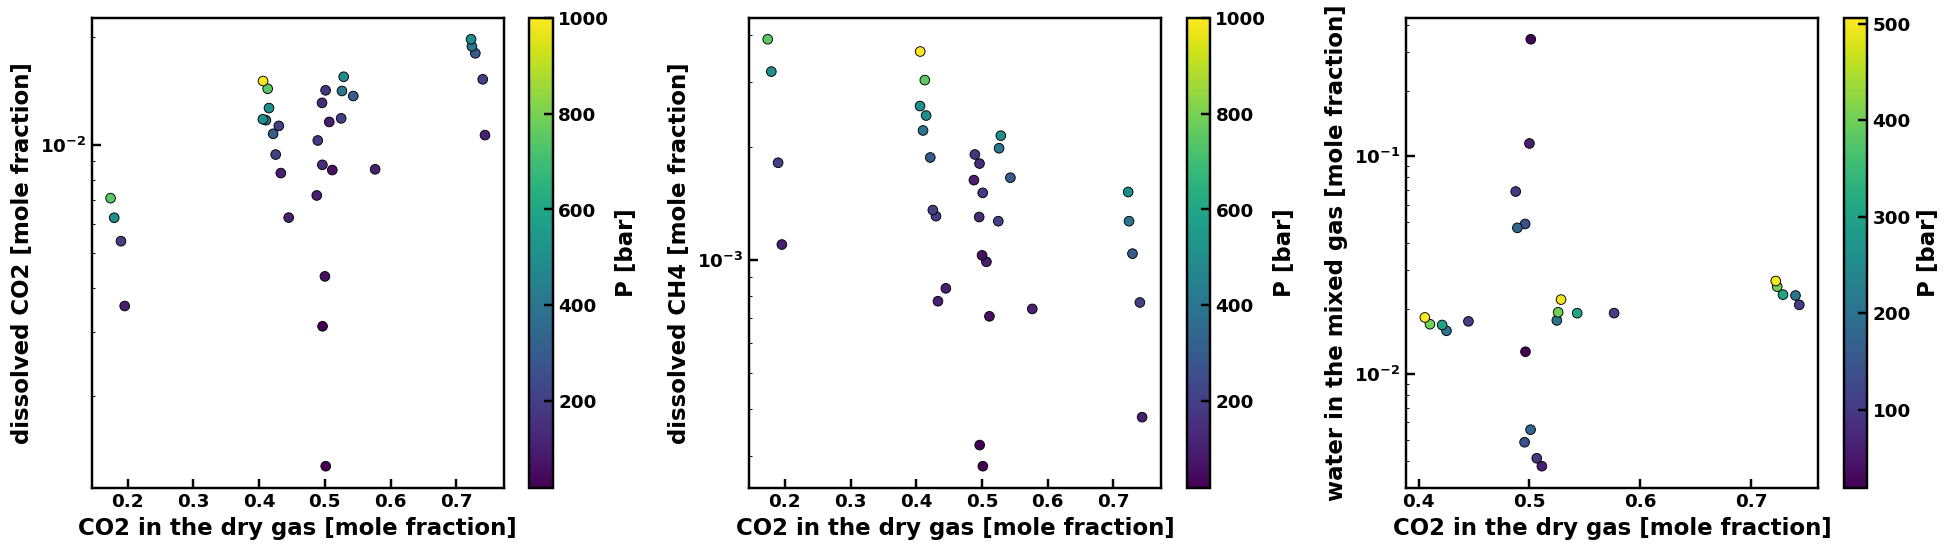

source          gas      property   
ALGHAFRI(2014)  ch4      xc_saltfree    10
                co2      xc_saltfree    10
                co2-ch4  y_h2o          10
DHIMA(1999)     ch4      xc_saltfree     9
                co2      xc_saltfree     9
QIN(2008)       ch4      xc_saltfree    15
                co2      xc_saltfree    15
                co2-ch4  y_h2o          15
dtype: int64


In [7]:
t = gbb.load("ternary", exclude_tags=None, exclude_flags=None).copy()
t["y_co2_dry"] = pd.to_numeric(t["y_co2_dry"], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for ax, (gas, prop, lab_) in zip(axes, [("co2", "xc_saltfree", "dissolved CO2 [mole fraction]"), ("ch4", "xc_saltfree", "dissolved CH4 [mole fraction]"), ("co2-ch4", "y_h2o", "water in the mixed gas [mole fraction]")]):
    g = t[(t.gas == gas) & (t.property == prop)]
    sc = ax.scatter(g.y_co2_dry, g.value, c=g.P_bar, cmap="viridis", s=40, edgecolor="black", linewidth=0.6, marker="o")
    plt.colorbar(sc, ax=ax, label="P [bar]"); V.lab(ax, "CO2 in the dry gas [mole fraction]", lab_)
    ax.set_yscale("log")
plt.tight_layout(); plt.show()
print(t.groupby(["source", "gas", "property"]).size())

## Enthalpy of solution of gases

`dh_sol` in kJ per mol of gas (negative: exothermic). Points carry the stated uncertainty where there is one (63 % of the rows).

{'o2': 60, 'co2': 22, 'c3h8': 12, 'c2h6': 9, 'ch4': 8}


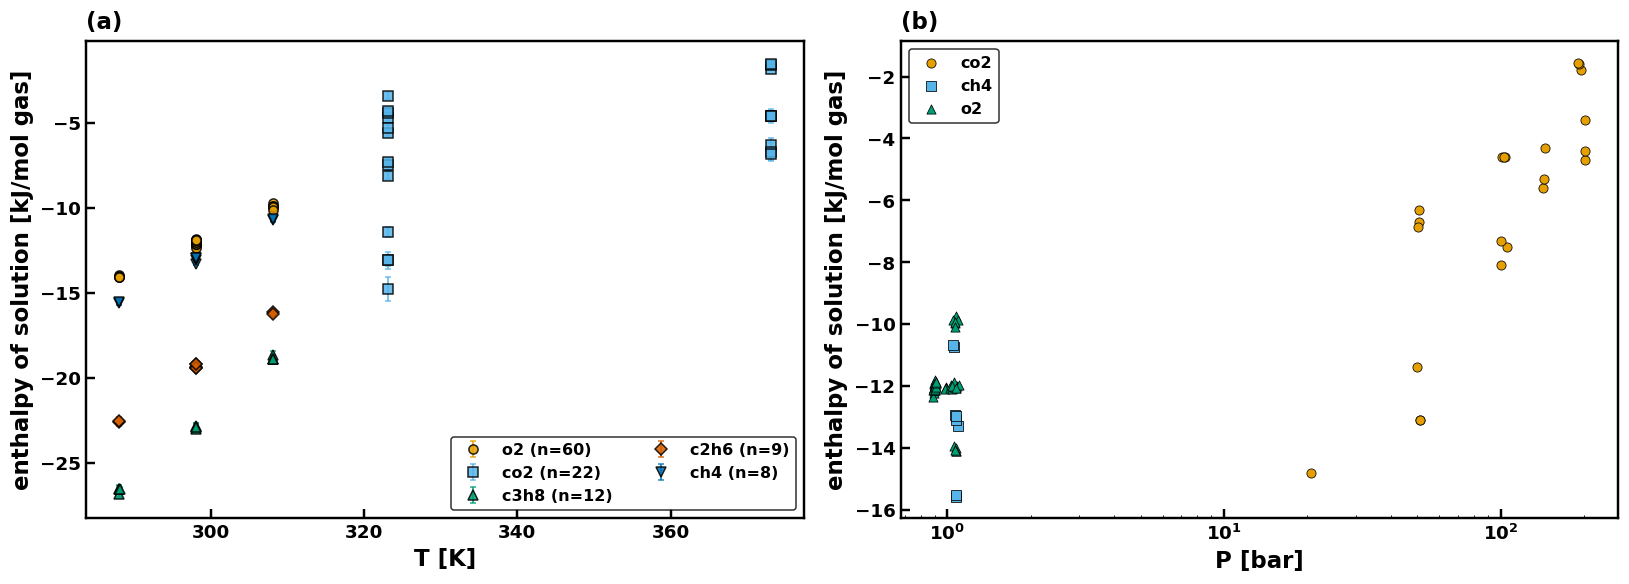

In [8]:
h = df[df.property == "dh_sol"]
print(h.groupby("gas").size().sort_values(ascending=False).to_dict())
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
top = h.gas.value_counts().index[:8]
for k, gas in enumerate(top):
    g = h[h.gas == gas]
    axes[0].errorbar(g.T_K, g.value, yerr=g.uncertainty.fillna(0), fmt=V.MARKERS[k % 12], color=V.WONG[(k + 1) % 7], mec="black", ms=6, elinewidth=1.2, capsize=2, alpha=0.85, label=f"{gas} (n={len(g)})")
axes[0].legend(ncol=2); V.lab(axes[0], "T [K]", "enthalpy of solution [kJ/mol gas]", "(a)")
g = h[h.gas.isin(["co2", "ch4", "o2"])]
for k, gas in enumerate(["co2", "ch4", "o2"]):
    w = g[g.gas == gas]
    axes[1].scatter(w.P_bar, w.value, s=36, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], edgecolor="black", linewidth=0.5, label=gas)
axes[1].set_xscale("log"); axes[1].legend(); V.lab(axes[1], "P [bar]", "enthalpy of solution [kJ/mol gas]", "(b)")
plt.tight_layout(); plt.show()